In [1]:
import numpy as np
from nuscenes.nuscenes import NuScenes,NuScenesExplorer
import torch
from torch.utils.data import Dataset,DataLoader
data_path = 'D:/Projects/Minor Project/Datasets/raw/nuScenes'
import cv2

In [2]:
nusc = NuScenes(version="v1.0-mini",dataroot=data_path,verbose=True)
explorer = NuScenesExplorer(nusc)

Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-lidarseg...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 lidarseg,
Done loading in 0.435 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:
class CustomDataset(Dataset):
    
    def __init__(self,nusc,explorer,sample_list):
        self.nusc = nusc
        self.explorer = explorer
        self.samples = sample_list
        self.scaled_u = 64/1600
        self.scaled_v = 64/900

    
    def __len__(self): 
        return len(self.samples)

    def __getitem__(self,index):
        sample = self.samples[index]

        cam_token = sample['data']['CAM_FRONT']
        lidar_token = sample['data']['LIDAR_TOP']

        points,coloring,image = self.explorer.map_pointcloud_to_image(lidar_token,cam_token)
        image_tensor = torch.from_numpy(np.array(image)).permute(2,0,1).float()

        mask = np.zeros((900, 1600), dtype=np.float32) 
        
        # Get all annotations for this sample
        for ann_token in sample['anns']:
            ann = self.nusc.get('sample_annotation', ann_token)
            
            # Filter for cars/trucks (adjust categories as needed)
            if 'vehicle' in ann['category_name']:
                # Project the 3D box to 2D image coordinates
                _, boxes, _ = self.explorer.view_points(ann['token'], cam_token)
                # You can use cv2.fillPoly to draw the box onto your mask
                # (Standard nuScenes devkit has helper functions for this)

        # 3. Scale mask to match model output (usually 256x256 for training loss)
        mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        depth_map = np.zeros((2,64,64),dtype=np.float32)

        u_cord = points[0,:]
        v_cord = points[1,:]
        
        for i in range(len(coloring)):
            u = int(u_cord[i] * self.scaled_u)
            v = int(v_cord[i] * self.scaled_v)

            if 0 <= u < 64 and 0 <= v < 64:
                if depth_map[0, v, u] == 0 or coloring[i] < depth_map[0, v, u]:
                    depth_map[0,v,u] = coloring[i]
                    depth_map[1,v,u] = 1.0

        return {
            "image": image_tensor,          # [3, 900, 1600]
            "depth_map": torch.from_numpy(depth_map), # [2, 64, 64]
            "gt_mask": torch.from_numpy(mask_resized).unsqueeze(0), # [1, 256, 256]
            "sample_token": sample['token']
        }



In [4]:
dataset = CustomDataset(nusc,explorer,nusc.sample)

train_loader = DataLoader(dataset,batch_size=4,shuffle=True,num_workers=0)

In [5]:
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from nuscenes.utils.geometry_utils import view_points

class CustomDataset2(Dataset):
    def __init__(self, nusc, explorer, sample_list):
        self.nusc = nusc
        self.explorer = explorer
        self.samples = sample_list
        # Scaling factors for 64x64 depth map
        self.scaled_u = 64/1600
        self.scaled_v = 64/900
        self.max_dist = 80.0 # Standard max distance for nuScenes LiDAR

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        cam_token = sample['data']['CAM_FRONT']
        lidar_token = sample['data']['LIDAR_TOP']

        # 1. Get Image
        # map_pointcloud_to_image returns the image and projected lidar points
        points, coloring, image = self.explorer.map_pointcloud_to_image(lidar_token, cam_token)
        image_tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1).float()

        # 2. Generate Ground Truth Segmentation Mask (900x1600)
        mask = np.zeros((900, 1600), dtype=np.float32)
        
        # Get boxes and camera intrinsics for projection
        _, boxes, camera_intrinsic = self.nusc.get_sample_data(cam_token)
        
        for box in boxes:
            # Focus on vehicles for this task
            if 'vehicle' in box.name:
                # Project 3D corners [3, 8] to 2D pixel coordinates [2, 8]
                pts_2d = view_points(box.corners(), camera_intrinsic, normalize=True)[:2, :]
                pts_2d = pts_2d.T.astype(np.int32)
                
                # Create a solid polygon from the projected 8 corners
                hull = cv2.convexHull(pts_2d)
                cv2.fillPoly(mask, [hull], 1.0)

        # Scale mask to 256x256 to match the SAM decoder's internal loss resolution
        mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        # 3. Generate Ground Truth Depth Map (64x64)
        # Channel 0: Normalized distance, Channel 1: Validity mask (1 if point exists)
        depth_map = np.zeros((2, 64, 64), dtype=np.float32)

        u_cord = points[0, :]
        v_cord = points[1, :]
        
        for i in range(len(coloring)):
            u = int(u_cord[i] * self.scaled_u)
            v = int(v_cord[i] * self.scaled_v)

            if 0 <= u < 64 and 0 <= v < 64:
                # Normalize distance by max_dist (0.0 to 1.0 range)
                norm_dist = min(coloring[i] / self.max_dist, 1.0)
                
                # Keep the closest point for each 64x64 cell
                if depth_map[0, v, u] == 0 or norm_dist < depth_map[0, v, u]:
                    depth_map[0, v, u] = norm_dist
                    depth_map[1, v, u] = 1.0 # Mark as a valid ground truth pixel

        return {
            "image": image_tensor,                              # [3, 900, 1600]
            "gt_depth": torch.from_numpy(depth_map),            # [2, 64, 64]
            "gt_mask": torch.from_numpy(mask_resized).unsqueeze(0), # [1, 256, 256]
            "sample_token": sample['token']
        }

In [12]:
dataset2 = CustomDataset2(nusc,explorer,nusc.sample)

train_loader = DataLoader(dataset,batch_size=4,shuffle=True,num_workers=0)

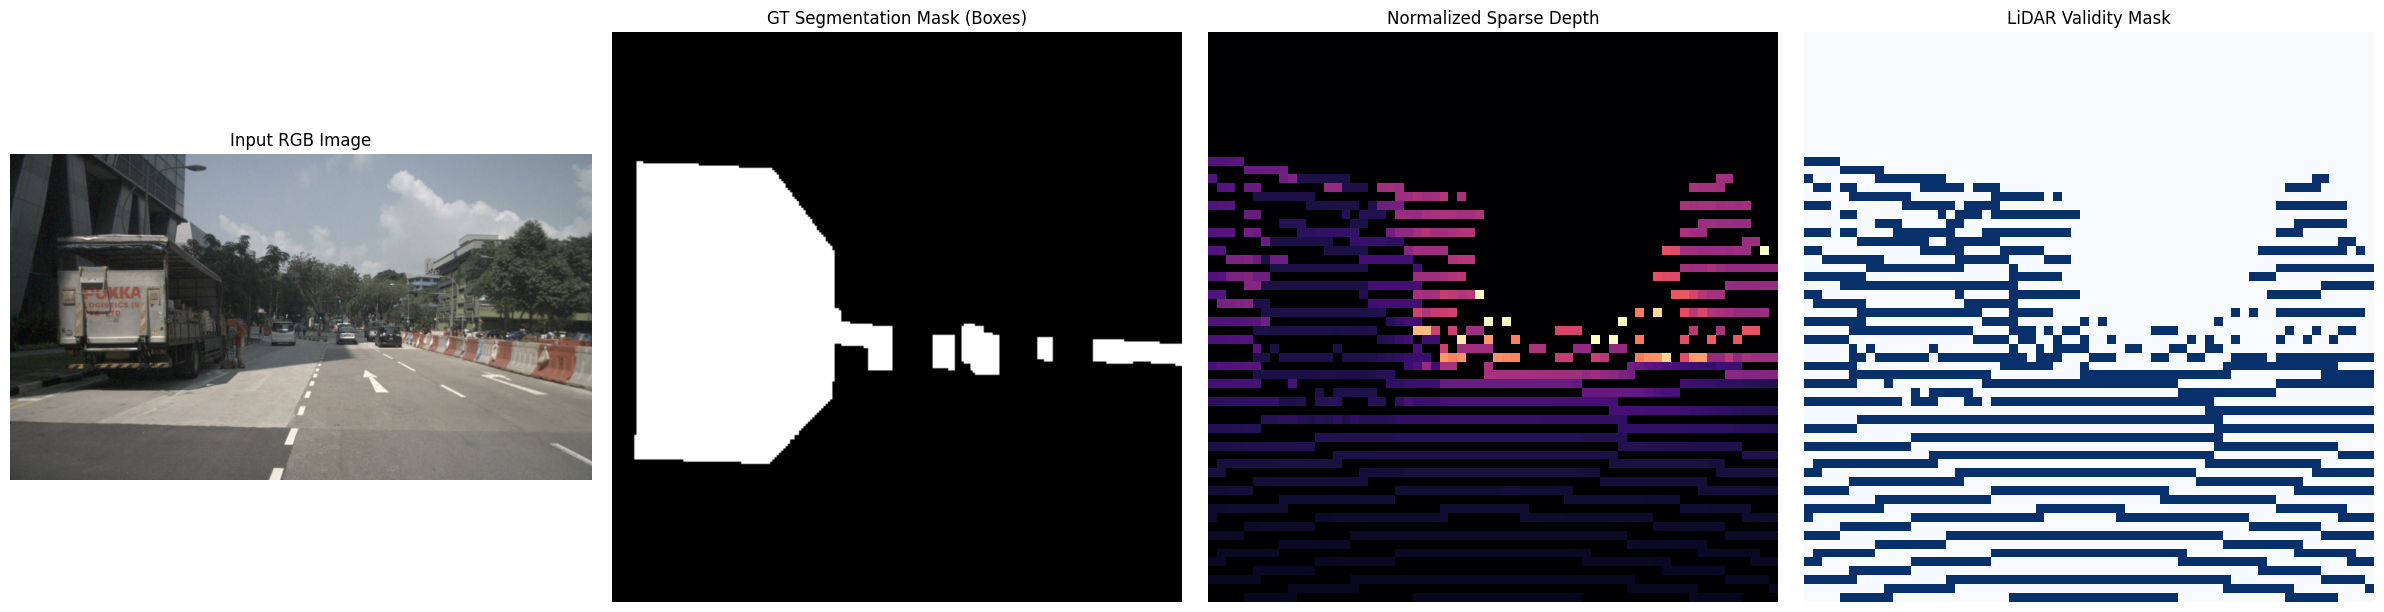

Image shape: (900, 1600, 3)
Mask shape: (256, 256)
Max depth value: 1.0000
Number of LiDAR points in 64x64 grid: 1215


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Initialize your dataset
# nusc, explorer, and sample_list should already be defined in your notebook
test_ds = CustomDataset2(nusc, explorer, nusc.sample)

# 2. Pull a single sample
data = test_ds[0]

# 3. Extract components
image = data['image'].permute(1, 2, 0).numpy().astype(np.uint8)
gt_mask = data['gt_mask'].squeeze().numpy()
# Get the depth channel (0) and the validity mask (1)
gt_depth = data['gt_depth'][0].numpy() 
valid_depth_mask = data['gt_depth'][1].numpy()

# 4. Visualization
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(image)
axes[0].set_title("Input RGB Image")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("GT Segmentation Mask (Boxes)")

# We use 'magma' for depth; points will be dark if close, bright if far
axes[2].imshow(gt_depth, cmap='magma')
axes[2].set_title("Normalized Sparse Depth")

axes[3].imshow(valid_depth_mask, cmap='Blues')
axes[3].set_title("LiDAR Validity Mask")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# 5. Check values
print(f"Image shape: {image.shape}") # Should be (900, 1600, 3)
print(f"Mask shape: {gt_mask.shape}")   # Should be (256, 256)
print(f"Max depth value: {gt_depth.max():.4f}") # Should be <= 1.0
print(f"Number of LiDAR points in 64x64 grid: {int(valid_depth_mask.sum())}")